# Metrics for Joint Simulation — Without Reference Data

## Initialization and Simulation

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from tqdm import tqdm

from leaspy.models import JointModel

In [26]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

# Load the model directly from the JSON file
model_path = "../models/PULSE_JOINT_100_ALSFRS_BMI_VC_MUSC_NFL_SNIP_10.json"
# model_path = "../models/PROACT_JOINT_100_ALSFRS_BMI_VC_MUSC_8.json"
# model_path = "../models/model_on_simulated_data_for_joint_100000_iterations.json"
model = JointModel.load(model_path)

### Parameters

#### For PULSE

In [27]:
visit_params_pulse = {
    "patient_number": 500,
    "visit_type": "random",
    "first_visit_mean": -2.660, 
    "first_visit_std": 3.950,    
    "time_follow_up_mean": 1.3397,
    "time_follow_up_std": 1.0575,
    "distance_visit_mean": 0.381, 
    "distance_visit_std": 0.05,    
    "min_spacing_between_visits": 1/365,
}

#### For PROACT

In [28]:
visit_params_proact = {
    "patient_number": 500,
    "visit_type": "random",
    "first_visit_mean": -2.712, 
    "first_visit_std": 3.075,    
    "time_follow_up_mean": 0.9472,
    "time_follow_up_std": 0.5435,
    "distance_visit_mean": 0.0854, 
    "distance_visit_std": 0.05,     
    "min_spacing_between_visits": 1/365,
}

In [29]:
if "PROACT" in model_path:
    visit_params = visit_params_proact
    print("Using PROACT visit parameters.")
elif "PULSE" in model_path:
    visit_params = visit_params_pulse
    print("Using PULSE visit parameters.")
else:
    
    from leaspy.io.data import Data
    from leaspy.datasets import load_dataset
    data = Data.from_dataframe(load_dataset("simulated_data_for_joint"), "joint")
    df_orig = data.to_dataframe()
    visit_params = {
    "patient_number": 50,
    "visit_type": "random",
    "data": data
    }
    print("Using visit parameters based on the simulated data for joint model.")

Using PULSE visit parameters.


### Simulation

In [30]:
from IPython.utils import io

with io.capture_output() as captured:
    M = 100

    sims = []
    for m in tqdm(range(M), desc="Simulations"):
        df_s = model.simulate(
            algorithm="joint_simulate",
            features=model.features,
            visit_parameters=visit_params,
        )
        sims.append(df_s.data.to_dataframe())

    display(sims[0].head())

## The Metrics

### Average Trajectory

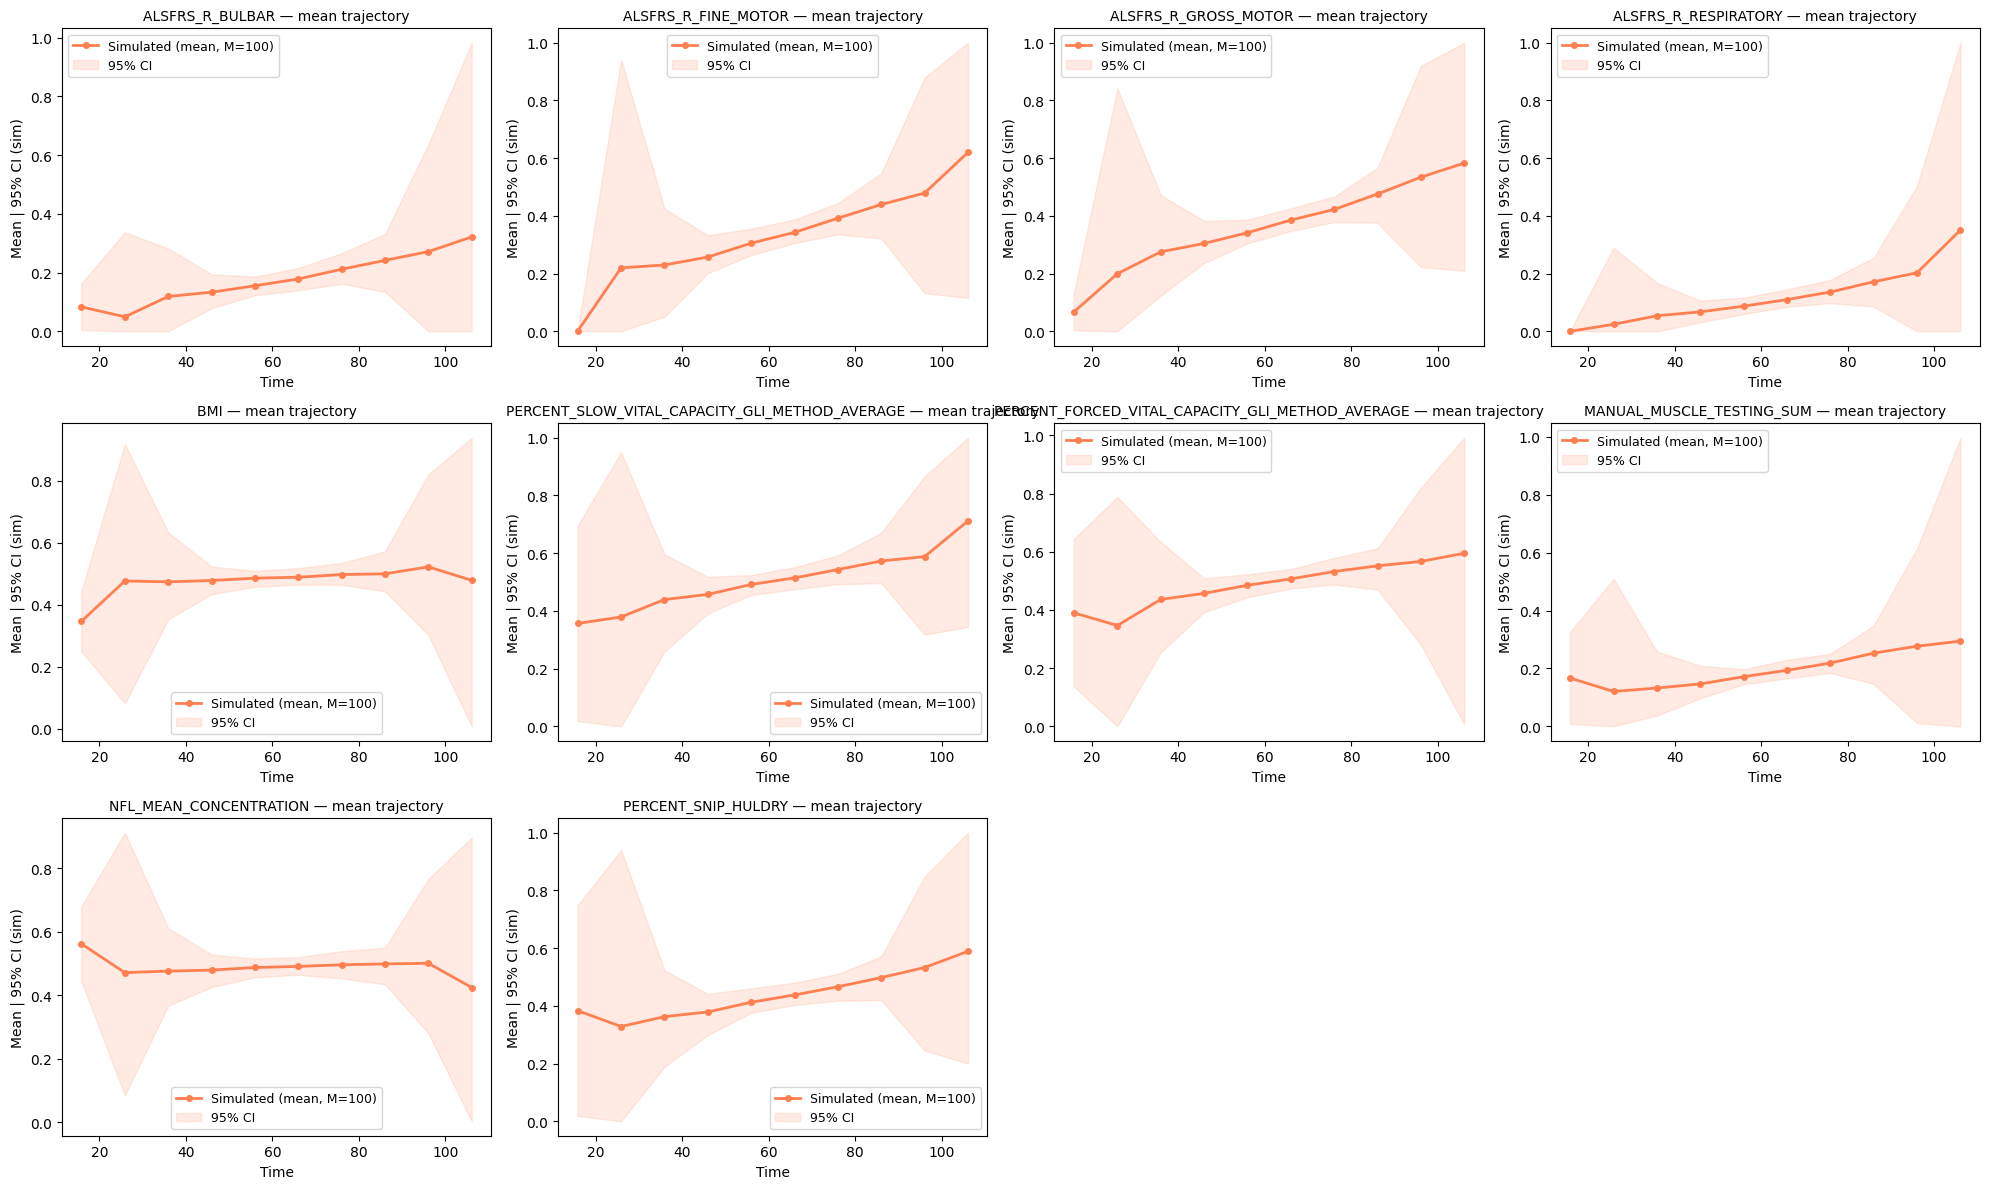

In [31]:
def trajectory_simulated(sims, outcome_cols, n_bins=10, max_plots_per_row=4):
    all_times = pd.concat([s['TIME'] for s in sims])
    all_bin_cats = pd.cut(all_times, bins=n_bins).cat.categories
    bin_centers = np.array([iv.mid for iv in all_bin_cats])

    n_outcomes = len(outcome_cols)
    n_cols = min(max_plots_per_row, n_outcomes)
    n_rows = int(np.ceil(n_outcomes / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), squeeze=False)
    axes_flat = axes.ravel()

    for ax, col in zip(axes_flat, outcome_cols):
        # Per-simulation bin means -> 95% CI across M sims
        sim_means = []
        for df_s in sims:
            ds2 = df_s.copy()
            ds2['_bin'] = pd.cut(ds2['TIME'], bins=all_bin_cats)
            m_s = ds2.groupby('_bin', observed=False)[col].mean().reindex(all_bin_cats).values
            sim_means.append(m_s)

        sim_means = np.array(sim_means)  # (M, n_bins)
        m_sim_avg = np.nanmean(sim_means, axis=0)
        m_sim_lo = np.nanpercentile(sim_means, 2.5, axis=0)
        m_sim_hi = np.nanpercentile(sim_means, 97.5, axis=0)

        ax.plot(
            bin_centers,
            m_sim_avg,
            marker='o',
            ms=4,
            lw=2,
            label=f'Simulated (mean, M={len(sims)})',
            color='coral'
        )
        ax.fill_between(
            bin_centers,
            np.where(np.isnan(m_sim_lo), np.nan, m_sim_lo),
            np.where(np.isnan(m_sim_hi), np.nan, m_sim_hi),
            alpha=0.15,
            color='coral',
            label='95% CI'
        )

        ax.set_title(f'{col} — mean trajectory', fontsize=10)
        ax.set_xlabel('Time')
        ax.set_ylabel('Mean | 95% CI (sim)')
        ax.legend(fontsize=9)

    # Hide unused subplot panels when n_outcomes is not a multiple of n_cols
    for ax in axes_flat[n_outcomes:]:
        ax.set_visible(False)

    plt.tight_layout()
    plt.show()

trajectory_simulated(sims, model.features)

### Kaplan-Meier

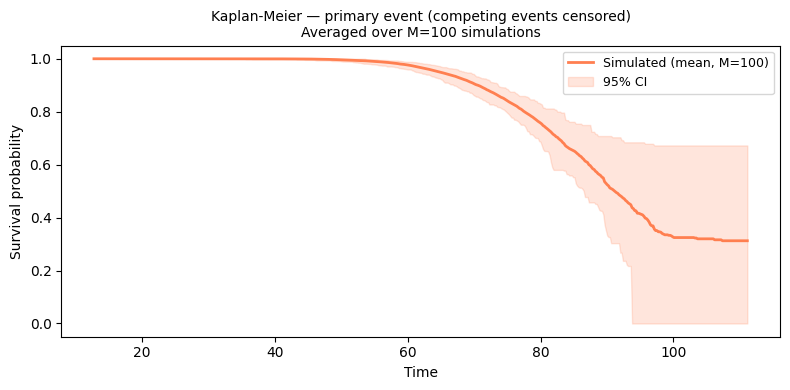

Event-type rates (simulated, mean +/- std over M=100):
  censored: 0.898 +/- 0.016
  primary event: 0.102 +/- 0.016
  competing event: 0.000 +/- 0.000


In [32]:

# Common time grid (derived from simulations)
t_min = min(s['EVENT_TIME'].min() for s in sims)
t_max = max(s['EVENT_TIME'].max() for s in sims)
t_grid = np.linspace(t_min, t_max, 500)

# KM for each simulation -> collect survival curves on the common grid
s_sims = []
event_rates = {k: [] for k in [0, 1, 2]}

for df_s in sims:
    surv_s = (
        df_s.drop_duplicates('ID')[['EVENT_TIME', 'EVENT_BOOL']]
        .dropna()
        .copy()
    )
    surv_s['event'] = (surv_s['EVENT_BOOL'] == 1).astype(int)
    kmf_s = KaplanMeierFitter()
    kmf_s.fit(surv_s['EVENT_TIME'], event_observed=surv_s['event'])
    s_sims.append(kmf_s.survival_function_at_times(t_grid).values)
    vc = surv_s['EVENT_BOOL'].value_counts(normalize=True)
    for k in [0, 1, 2]:
        event_rates[k].append(vc.get(k, 0.0))

s_sims     = np.array(s_sims)          # (M, 500)
s_sim_mean = s_sims.mean(axis=0)
s_sim_lo   = np.percentile(s_sims, 2.5, axis=0)
s_sim_hi   = np.percentile(s_sims, 97.5, axis=0)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(t_grid, s_sim_mean, color='coral', lw=2, label=f'Simulated (mean, M={M})')
ax.fill_between(t_grid, s_sim_lo, s_sim_hi,
                alpha=0.2, color='coral', label='95% CI')
ax.set_title(
    f'Kaplan-Meier — primary event (competing events censored)\n'
    f'Averaged over M={M} simulations',
    fontsize=10
)
ax.set_xlabel('Time')
ax.set_ylabel('Survival probability')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# Event-type breakdown
names = {0: 'censored', 1: 'primary event', 2: 'competing event'}
print(f'Event-type rates (simulated, mean +/- std over M={M}):')
for k in [0, 1, 2]:
    vals = event_rates[k]
    print(f"  {names[k]}: {np.mean(vals):.3f} +/- {np.std(vals):.3f}")


### Histograms for time

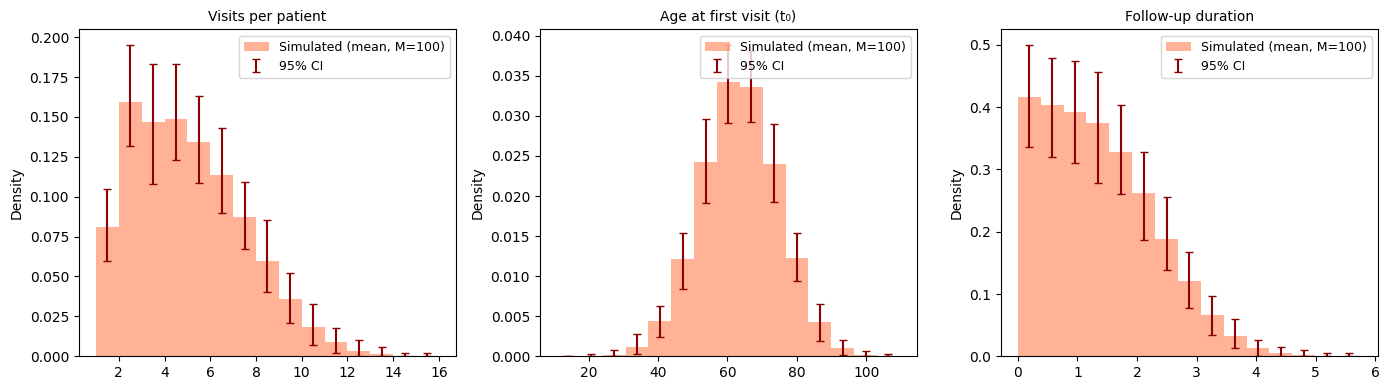

,Metric,Mean (sim avg),SD (sim avg)
0,n_visits,4.557,2.436
1,age_first_visit,63.479,11.086
2,followup_duration,1.352,0.924


In [33]:

def visit_process_metrics_simulated(sims):
    n_per  = [s.groupby('ID').size().values for s in sims]
    t0_per = [s.groupby('ID')['TIME'].min().values for s in sims]
    fu_per = [s.groupby('ID')['TIME'].apply(lambda x: x.max() - x.min()).values for s in sims]

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    for ax, (b_list, title) in zip(axes, [
        (n_per,  'Visits per patient'),
        (t0_per, 'Age at first visit (t₀)'),
        (fu_per, 'Follow-up duration'),
    ]):
        all_vals  = np.concatenate(b_list)
        bin_edges = np.linspace(all_vals.min(), all_vals.max(), 16)
        bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

        all_densities = np.array([
            np.histogram(b, bins=bin_edges, density=True)[0] for b in b_list
        ])
        mean_d = all_densities.mean(axis=0)
        lo_d   = np.maximum(np.percentile(all_densities, 2.5, axis=0), 0)
        hi_d   = np.percentile(all_densities, 97.5, axis=0)

        ax.bar(bin_centers, mean_d, width=np.diff(bin_edges),
               alpha=0.6, label=f'Simulated (mean, M={len(sims)})', color='coral')
        ax.errorbar(bin_centers, mean_d,
                    yerr=[np.maximum(mean_d - lo_d, 0), np.maximum(hi_d - mean_d, 0)],
                    fmt='none', color='darkred', capsize=3, label='95% CI')

        ax.set_title(title, fontsize=10)
        ax.legend(fontsize=9)
        ax.set_ylabel('Density')
        ax.set_ylim(bottom=0)

    plt.tight_layout()
    plt.show()

    summary = pd.DataFrame({
        'Metric':         ['n_visits', 'age_first_visit', 'followup_duration'],
        'Mean (sim avg)': [np.mean([b.mean() for b in n_per]),
                           np.mean([b.mean() for b in t0_per]),
                           np.mean([b.mean() for b in fu_per])],
        'SD (sim avg)':   [np.mean([b.std() for b in n_per]),
                           np.mean([b.std() for b in t0_per]),
                           np.mean([b.std() for b in fu_per])],
    }).round(3)
    return summary

visit_summary = visit_process_metrics_simulated(sims)
display(visit_summary)


In [34]:

# --- Diagnosis: patients with a single visit (follow-up == 0) ---

# Simulations: distribution of the single-visit count across M runs
single_visit_counts = []
for df_s in sims:
    nv = df_s.groupby('ID').size()
    single_visit_counts.append((nv == 1).sum())

sv_arr = np.array(single_visit_counts)
sv_lo  = np.percentile(sv_arr, 2.5)
sv_hi  = np.percentile(sv_arr, 97.5)

print(f"Simulations (M={M}):")
print(f"  Patients with exactly 1 visit : {sv_arr.mean():.1f} / {visit_params['patient_number']}"
      f" ({100 * sv_arr.mean() / visit_params['patient_number']:.1f}%) — 95% CI [{sv_lo:.1f}, {sv_hi:.1f}]")


Simulations (M=100):
  Patients with exactly 1 visit : 40.4 / 500 (8.1%) — 95% CI [30.0, 52.5]


Plotting trajectories for single-visit patients in 100/100 simulations.


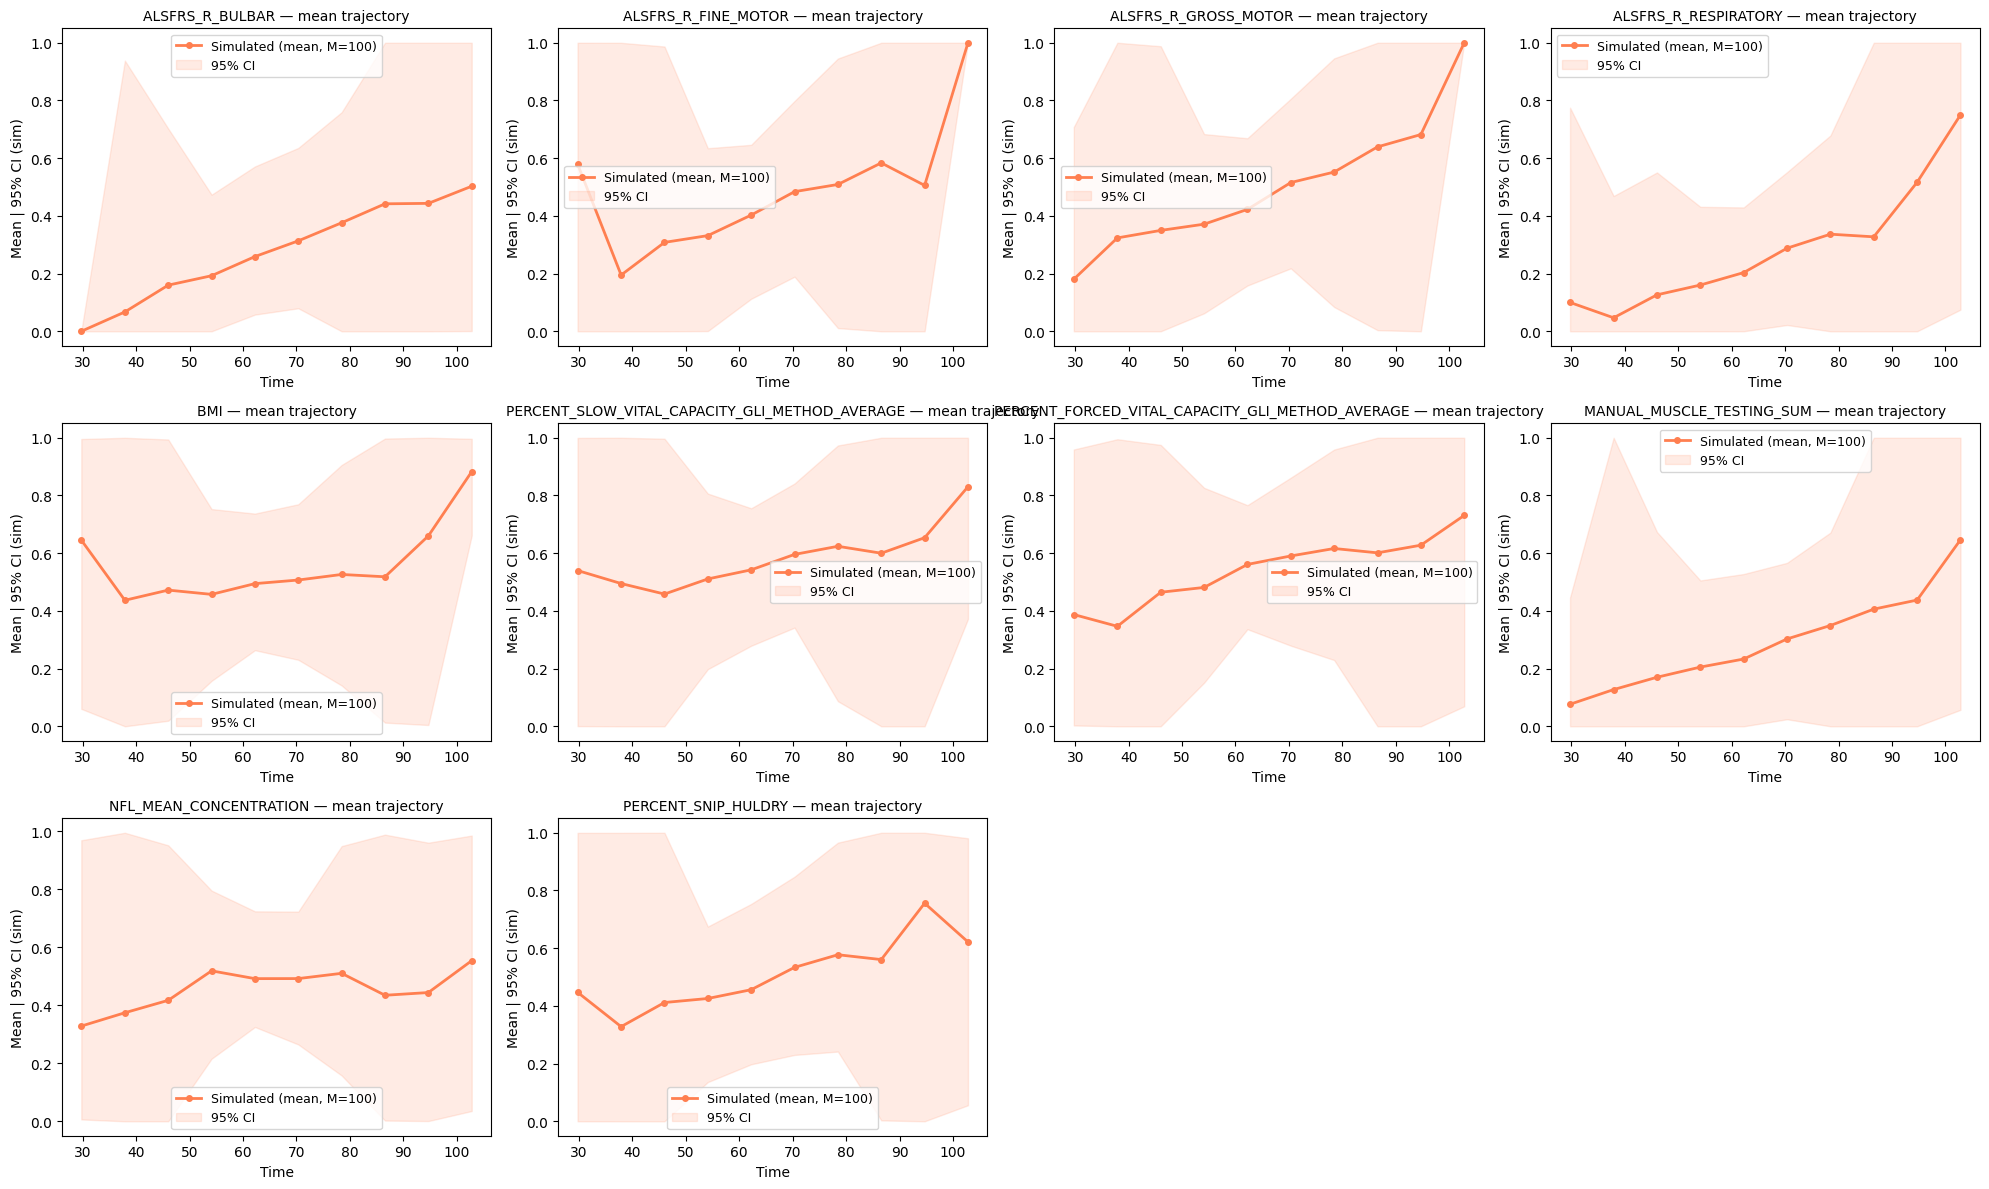

In [35]:
# Trajectories restricted to patients with exactly one visit
single_visit_sims = []
for df_s in sims:
    n_visits = df_s.groupby('ID').size()
    single_visit_ids = n_visits[n_visits == 1].index
    df_single = df_s[df_s['ID'].isin(single_visit_ids)].copy()
    single_visit_sims.append(df_single)

single_visit_sims_non_empty = [df for df in single_visit_sims if not df.empty]

if len(single_visit_sims_non_empty) == 0:
    print('No patients with exactly one visit were found in any simulation.')
else:
    print(
        f"Plotting trajectories for single-visit patients in "
        f"{len(single_visit_sims_non_empty)}/{len(single_visit_sims)} simulations."
    )
    trajectory_simulated(single_visit_sims_non_empty, model.features)

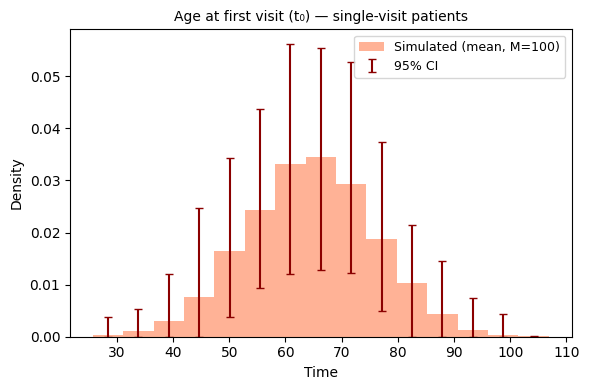

In [36]:

# --- Histograms for single-visit patients ---

if len(single_visit_sims_non_empty) == 0:
    print("No single-visit patients found in any simulation.")
else:
    t0_per_sv = [
        df_s.groupby('ID')['TIME'].min().values
        for df_s in single_visit_sims_non_empty
    ]

    all_vals = np.concatenate(t0_per_sv)
    bin_edges = np.linspace(all_vals.min(), all_vals.max(), 16)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    all_densities = np.array([
        np.histogram(b, bins=bin_edges, density=True)[0] for b in t0_per_sv
    ])
    mean_d = all_densities.mean(axis=0)
    lo_d   = np.maximum(np.percentile(all_densities, 2.5, axis=0), 0)
    hi_d   = np.percentile(all_densities, 97.5, axis=0)

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.bar(bin_centers, mean_d, width=np.diff(bin_edges),
           alpha=0.6, label=f'Simulated (mean, M={len(single_visit_sims_non_empty)})', color='coral')
    ax.errorbar(bin_centers, mean_d,
                yerr=[np.maximum(mean_d - lo_d, 0), np.maximum(hi_d - mean_d, 0)],
                fmt='none', color='darkred', capsize=3, label='95% CI')

    ax.set_title('Age at first visit (t₀) — single-visit patients', fontsize=10)
    ax.set_xlabel('Time')
    ax.set_ylabel('Density')
    ax.set_ylim(bottom=0)
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()
